# CLIP 이미지 클러스터링 (Colab 버전)

CLIP으로 이미지를 임베딩하고 K-means로 클러스터링한 뒤, Gemini Vision으로 각 클러스터의 시각적 주제를 도출합니다.

**Colab 설정**: 런타임 → 런타임 유형 변경 → **T4 GPU** 선택 권장  
**HF_TOKEN**: 불필요 (`openai/clip-vit-base-patch32`는 공개 모델)  
**TPU**: 미지원 (PyTorch-XLA 설정 복잡, GPU/CPU로 충분)

In [1]:
# ── 패키지 설치 (Colab에 없는 것만)
!pip install -q transformers pillow requests google-genai scikit-learn python-dotenv

In [2]:
# ── 라이브러리 임포트
import os, io, json, time
import requests
import numpy as np
from PIL import Image

import torch
from transformers import CLIPModel, CLIPProcessor

import matplotlib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

%matplotlib inline

# 한글 폰트 설치 (그래프 한글 레이블용, 선택사항)
import subprocess
subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], capture_output=True)
from matplotlib import font_manager as fm
nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(nanum_path):
    fm.fontManager.addfont(nanum_path)
    matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [3]:
# ── API 키 설정
# 방법 1: 직접 입력 (간단하지만 공유 시 노출 주의)
# GEMINI_API_KEY = ""  # 여기에 입력하거나 아래 방법 2 사용

# 방법 2: Colab Secrets 사용 (권장)
# 왼쪽 패널 🔑 아이콘 → GEMINI_API_KEY 이름으로 등록 후 아래 주석 해제
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

USE_GEMINI = bool(GEMINI_API_KEY)  # API 키 없으면 Gemini 명명 단계 건너뜀
print(f'Gemini Vision 사용: {USE_GEMINI}')

Gemini Vision 사용: True


In [4]:
# ── 분석할 이미지 목록
# URL과 로컬 경로(/content/... 또는 Google Drive 마운트 경로) 혼용 가능
IMAGES = [
    # --- 자연 풍경 ---
    'https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=600',
    'https://images.unsplash.com/photo-1469474968028-56623f02e42e?w=600',
    'https://images.unsplash.com/photo-1439066615861-d1af74d74000?w=600',
    'https://images.unsplash.com/photo-1507525428034-b723cf961d3e?w=600',
    # --- 도시·빌딩 ---
    'https://images.unsplash.com/photo-1480714378408-67cf0d13bc1b?w=600',
    'https://images.unsplash.com/photo-1449034446853-66c86144b0ad?w=600',
    'https://images.unsplash.com/photo-1444723121867-7a241cacace9?w=600',
    # --- 음식 ---
    'https://images.unsplash.com/photo-1565299624946-b28f40a0ae38?w=600',
    'https://images.unsplash.com/photo-1567620905732-2d1ec7ab7445?w=600',
    'https://images.unsplash.com/photo-1546069901-ba9599a7e63c?w=600',
    # --- 동물 ---
    'https://images.unsplash.com/photo-1543852786-1cf6624b9987?w=600',
    'https://images.unsplash.com/photo-1517849845537-4d257902454a?w=600',
    'https://images.unsplash.com/photo-1535268647677-300dbf3d78d1?w=600',
    # --- 자동차 ---
    'https://images.unsplash.com/photo-1503376780353-7e6692767b70?w=600',
    'https://images.unsplash.com/photo-1494976388531-d1058494cdd8?w=600',
    'https://images.unsplash.com/photo-1542362567-b07e54358753?w=600',
]

# Google Drive의 이미지 폴더 전체를 쓰려면:
# from google.colab import drive
# drive.mount('/content/drive')
# from pathlib import Path
# IMAGES = [str(p) for p in Path('/content/drive/MyDrive/photos').glob('*.jpg')]

print(f'이미지 {len(IMAGES)}개')

이미지 16개


In [7]:
 # ── 핵심 함수 정의

def load_image(source):
    if source.startswith(('http://', 'https://')):
        resp = requests.get(source, headers={'User-Agent': 'Mozilla/5.0'}, timeout=20)
        resp.raise_for_status()
        img = Image.open(io.BytesIO(resp.content))
    else:
        img = Image.open(source)
    return img.convert('RGB')


def embed_images_with_clip(sources, model_name='openai/clip-vit-base-patch32', batch_size=16):
    print(f'  Device: {device}')
    model = CLIPModel.from_pretrained(model_name).to(device).eval()
    processor = CLIPProcessor.from_pretrained(model_name)

    images, valid_sources = [], []
    for src in sources:
        try:
            images.append(load_image(src))
            valid_sources.append(src)
        except Exception as e:
            print(f'  로드 실패: {src[:60]} ({e})')
    print(f'  로드 성공: {len(images)} / {len(sources)}')

    all_vecs = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        inputs = processor(images=batch, return_tensors='pt').to(device)
        with torch.no_grad():
            features = model.get_image_features(**inputs)
        if not isinstance(features, torch.Tensor):
            for attr in ('image_embeds', 'pooler_output'):
                t = getattr(features, attr, None)
                if t is not None:
                    features = t
                    break
            else:
                features = features.last_hidden_state[:, 0]
        features = features / features.norm(dim=-1, keepdim=True)
        all_vecs.append(features.cpu().numpy())

    return np.concatenate(all_vecs, axis=0), valid_sources, images


def find_optimal_k(X, k_range=(2, 9)):
    ks = list(range(k_range[0], k_range[1]))
    inertias, silhouettes = [], []

    print(f'  K 탐색 ({ks[0]} ~ {ks[-1]})')
    print(f"  {'K':>3} | {'inertia':>10} | {'silhouette':>11}")
    print('  ' + '-' * 35)
    for k in ks:
        km = KMeans(n_clusters=k, n_init=20, random_state=42)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil = silhouette_score(X, labels)
        silhouettes.append(sil)
        print(f'  {k:>3} | {km.inertia_:>10.3f} | {sil:>11.4f}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(ks, inertias, 'o-', color='steelblue', lw=2)
    ax1.set_xlabel('K (클러스터 수)')
    ax1.set_ylabel('Inertia (WCSS)')
    ax1.set_title('엘보우 (Elbow Method)')
    ax1.grid(alpha=0.3)

    best_idx = int(np.argmax(silhouettes))
    ax2.plot(ks, silhouettes, 'o-', color='darkorange', lw=2)
    ax2.axvline(ks[best_idx], color='red', linestyle='--', alpha=0.6,
                label=f'max @ K={ks[best_idx]}')
    ax2.set_xlabel('K (클러스터 수)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('실루엣 점수')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('k_selection_image.png', dpi=120, bbox_inches='tight')
    plt.show()

    return ks[best_idx], ks, silhouettes


def save_cluster_grid(reps_pil, cluster_sizes, save_path='cluster_grid_image.png'):
    n_clusters = len(reps_pil)
    n_cols = max(len(v) for v in reps_pil.values())
    fig, axes = plt.subplots(n_clusters, n_cols,
                             figsize=(2.2 * n_cols, 2.2 * n_clusters))
    if n_clusters == 1:
        axes = np.array([axes])
    for row, c in enumerate(sorted(reps_pil.keys())):
        for col in range(n_cols):
            ax = axes[row, col] if n_cols > 1 else axes[row]
            ax.axis('off')
            if col < len(reps_pil[c]):
                ax.imshow(reps_pil[c][col])
                if col == 0:
                    ax.set_ylabel(f'C{c}\n(n={cluster_sizes[c]})',
                                  rotation=0, labelpad=30, fontsize=11, fontweight='bold')
    plt.suptitle('클러스터별 대표 이미지', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  그리드 저장: {save_path}')


def name_cluster_with_gemini(image_paths):
    from google import genai
    from google.genai import types
    client = genai.Client(api_key=GEMINI_API_KEY)
    parts = []
    for p in image_paths:
        img = load_image(p)
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=85)
        parts.append(types.Part.from_bytes(data=buf.getvalue(), mime_type='image/jpeg'))
    parts.append(types.Part.from_text(text="""위 이미지들은 K-means로 한 클러스터에 묶였다.
이 클러스터의 공통 시각·주제 특징을 도출해 아래 JSON 형식으로만 답하라.

{"topic_name": "15자 이내 주제명", "visual_features": "공통 색감·구도·소재 (1~2문장)",
 "subject": "주제·맥락 (1~2문장)", "keywords": ["키워드1","키워드2","키워드3","키워드4","키워드5"]}"""))
    resp = client.models.generate_content(
        model='gemini-2.5-flash', contents=parts,
        config=types.GenerateContentConfig(response_mime_type='application/json'))
    return json.loads(resp.text)

print('함수 정의 완료')

함수 정의 완료


## 1단계: CLIP 임베딩
이미지를 다운로드하고 CLIP으로 벡터화합니다. 결과는 `embeddings_image.json`에 캐시됩니다.

In [8]:
EMBEDDINGS_PATH = 'embeddings_image.json'

# 캐시 확인 후 임베딩
if os.path.exists(EMBEDDINGS_PATH):
    with open(EMBEDDINGS_PATH, encoding='utf-8') as f:
        cached = json.load(f)
    if cached.get('sources_input') == list(IMAGES):
        print(f'캐시 재사용: {EMBEDDINGS_PATH} ({len(IMAGES)}개)')
    else:
        print('이미지 목록 변경 감지 → 재임베딩')
        os.remove(EMBEDDINGS_PATH)

if not os.path.exists(EMBEDDINGS_PATH):
    print(f'[1/3] 이미지 {len(IMAGES)}개 CLIP 임베딩 중...')
    X_raw, valid_sources, _ = embed_images_with_clip(IMAGES)
    X_raw = normalize(X_raw, norm='l2')
    payload = {
        'model': 'openai/clip-vit-base-patch32',
        'dim': int(X_raw.shape[1]),
        'n_images': len(valid_sources),
        'sources_input': list(IMAGES),
        'sources': valid_sources,
        'embeddings': X_raw.tolist(),
    }
    with open(EMBEDDINGS_PATH, 'w', encoding='utf-8') as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)
    print(f'저장: {EMBEDDINGS_PATH}  shape={X_raw.shape}')

[1/3] 이미지 16개 CLIP 임베딩 중...
  Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

  로드 성공: 16 / 16
저장: embeddings_image.json  shape=(16, 512)


## 2단계: 최적 K 탐색
엘보우·실루엣 그래프를 보고 아래 셀에서 `BEST_K`를 원하는 값으로 변경하세요.

입력 shape: (16, 512)
  K 탐색 (2 ~ 8)
    K |    inertia |  silhouette
  -----------------------------------
    2 |      5.413 |      0.1061
    3 |      4.359 |      0.1501
    4 |      3.491 |      0.1979
    5 |      2.994 |      0.1634
    6 |      2.597 |      0.1501
    7 |      2.224 |      0.1573
    8 |      1.905 |      0.1326


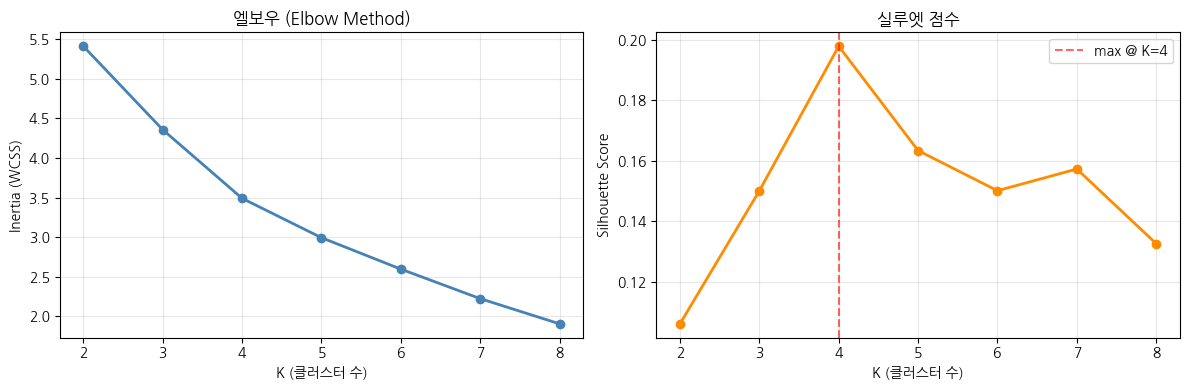


실루엣 기준 추천 K = 4
▶ 아래 셀에서 BEST_K 값을 확인·수정 후 실행하세요.


In [9]:
# embeddings 로드
with open(EMBEDDINGS_PATH, encoding='utf-8') as f:
    data = json.load(f)
X = normalize(np.array(data['embeddings'], dtype=float), norm='l2')
sources = data['sources']
print(f'입력 shape: {X.shape}')

# 엘보우·실루엣 그래프 → 자동 추천 K 출력
max_k = min(9, len(sources) - 1)
suggested_k, valid_ks, silhouettes = find_optimal_k(X, k_range=(2, max_k))
print(f'\n실루엣 기준 추천 K = {suggested_k}')
print(f'▶ 아래 셀에서 BEST_K 값을 확인·수정 후 실행하세요.')

In [10]:
# ★ 그래프를 보고 원하는 K로 변경하세요 (기본값 = 자동 추천)
BEST_K = suggested_k  # ← 여기를 5, 6 등 원하는 숫자로 바꿔도 됩니다

print(f'선택한 K = {BEST_K}')

선택한 K = 4


## 3단계: 클러스터링 분석
K-means 실행 → 대표 이미지 그리드 생성 → Gemini Vision으로 클러스터 주제 명명

[3/3] K=4으로 K-means 실행
저장: clusters_image.json

[Cluster 0]  n=3
  ▸ 주제명   : 먹음직스러운 음식 사진
  ▸ 시각특징 : 다채로운 식재료와 따뜻하거나 밝은 조명을 활용하여 음식의 질감과 색감을 부각시킨 전문가적인 음식 사진입니다. 주로 위에서 내려다보는 구도로 촬영되었습니다.
  ▸ 맥락     : 피자, 샐러드, 팬케이크 등 다양한 종류의 조리된 식사 메뉴들을 먹음직스럽게 연출하여 시각적인 만족감을 높이는 데 중점을 둡니다.
  ▸ 키워드   : 음식, 요리, 식사, 먹음직스러운, 음식_사진
    1. (d=0.3899) https://images.unsplash.com/photo-1565299624946-b28f40a0ae38?w=600
    2. (d=0.4081) https://images.unsplash.com/photo-1546069901-ba9599a7e63c?w=600
    3. (d=0.4131) https://images.unsplash.com/photo-1567620905732-2d1ec7ab7445?w=600

[Cluster 1]  n=7
  ▸ 주제명   : 골든아워 자연 풍경
  ▸ 시각특징 : 공통적으로 따뜻한 노을빛과 청량한 푸른빛이 조화를 이루며 광활한 자연 경관을 담고 있습니다. 해 질 녘 또는 해 뜰 녘의 부드러운 빛과 넓은 구도가 특징입니다.
  ▸ 맥락     : 해 질 녘이나 해 뜰 녘의 황금 시간대에 포착된 자연의 아름다움과 장엄함을 주제로 합니다. 평화롭고 고요하며 때로는 웅장한 분위기를 자아냅니다.
  ▸ 키워드   : 골든아워, 자연 경관, 일몰/일출, 장엄함, 평온함
    1. (d=0.4611) https://images.unsplash.com/photo-1507525428034-b723cf961d3e?w=600
    2. (d=0.4665) https://images.unsplash.com/photo-1449034446853-66c86144

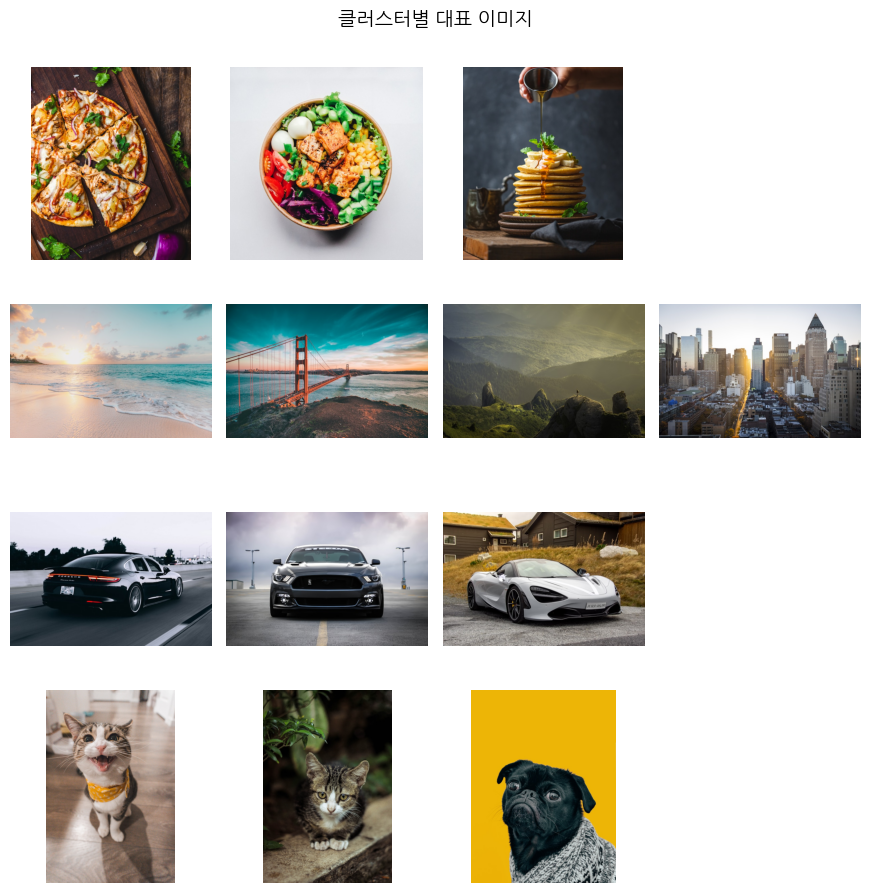

  그리드 저장: cluster_grid_image.png


In [11]:
CLUSTERS_PATH = 'clusters_image.json'
GRID_PATH = 'cluster_grid_image.png'
N_REPS = 4  # 그리드에 표시할 클러스터당 대표 이미지 수

print(f'[3/3] K={BEST_K}으로 K-means 실행')
km = KMeans(n_clusters=BEST_K, n_init=30, random_state=42)
labels = km.fit_predict(X)

clusters = []
reps_pil = {}
cluster_sizes = {}

for c in sorted(set(labels)):
    idx = np.where(labels == c)[0]
    center = X[idx].mean(axis=0)
    dists = np.linalg.norm(X[idx] - center, axis=1)
    order = np.argsort(dists)

    members = []
    for rank, pos in enumerate(order, start=1):
        image_id = int(idx[pos])
        members.append({
            'rank': rank,
            'image_id': image_id,
            'distance_to_center': float(dists[pos]),
            'source': sources[image_id],
        })

    cluster_info = {'cluster_id': int(c), 'size': int(len(idx)), 'members': members}

    rep_sources = [m['source'] for m in members[:N_REPS]]
    rep_pils = []
    for src in rep_sources:
        try:
            rep_pils.append(load_image(src))
        except Exception as e:
            print(f'  [경고] 로드 실패: {src[:60]} ({e})')
    reps_pil[int(c)] = rep_pils
    cluster_sizes[int(c)] = int(len(idx))

    if USE_GEMINI:
        try:
            topic = name_cluster_with_gemini(rep_sources[:3])
            cluster_info.update(topic)
            time.sleep(0.5)
        except Exception as e:
            cluster_info['topic_error'] = str(e)

    clusters.append(cluster_info)

# 저장
with open(CLUSTERS_PATH, 'w', encoding='utf-8') as f:
    json.dump({'k': int(BEST_K), 'n_images': len(sources), 'clusters': clusters},
              f, ensure_ascii=False, indent=2)
print(f'저장: {CLUSTERS_PATH}')

# 콘솔 출력
print('=' * 70)
for cl in clusters:
    print(f"\n[Cluster {cl['cluster_id']}]  n={cl['size']}")
    if 'topic_name' in cl:
        print(f"  ▸ 주제명   : {cl['topic_name']}")
        print(f"  ▸ 시각특징 : {cl['visual_features']}")
        print(f"  ▸ 맥락     : {cl['subject']}")
        print(f"  ▸ 키워드   : {', '.join(cl['keywords'])}")
    elif 'topic_error' in cl:
        print(f"  (주제 도출 실패: {cl['topic_error']})")
    for m in cl['members'][:3]:
        print(f"    {m['rank']}. (d={m['distance_to_center']:.4f}) {m['source'][:75]}")

# 대표 이미지 그리드
save_cluster_grid(reps_pil, cluster_sizes, save_path=GRID_PATH)

In [ ]:
# (선택) 결과 파일 다운로드
from google.colab import files
files.download('k_selection_image.png')
files.download('cluster_grid_image.png')
files.download('clusters_image.json')